1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

2. Load Dataset

In [ ]:
df = pd.read_csv("customer_churn_nn.csv")

df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


**Task 1: Dataset Understanding**

Dataset Shape

In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (2000, 17)


Data Types

In [ ]:
print(df.dtypes)

customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


Missing Values

In [ ]:
print(df.isnull().sum())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


Statistical Summary

In [ ]:
print(df.describe())

       tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min         1.000000           255.450000                  0.000000   
25%        15.000000           427.782500                 15.000000   
50%        23.000000           688.355000                 18.000000   
75%        33.000000          1007.372500                 22.000000   
max        72.000000          2156.520000                 30.000000   

       support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
count                   2000.000000         2000.000000    2000.000000   
mean                       1.953000            3.555000      90.007625   
std                        1.463852            3.885682      53.215719   
min                        0.000000            0.000000       0.

Target Distribution

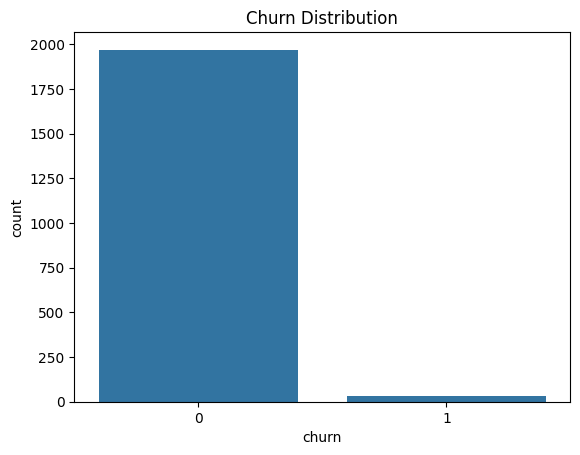

In [ ]:
sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()

Target Variable Interpretation

In [ ]:
print(df['churn'].value_counts())

churn
0    1969
1      31
Name: count, dtype: int64


**Task 2: Data Preprocessing**

Remove Identifier Column

In [ ]:
df.drop('customer_id', axis=1, inplace=True)

Separate Features and Target

In [ ]:
X = df.drop('churn', axis=1)
y = df['churn']

Identify Categorical and Numerical Columns

In [ ]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

Preprocessing Pipeline

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Apply Preprocessing

In [ ]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

**Task 3: Neural Network Model Building**

Build Model

In [ ]:
model = Sequential()

model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

**Task 4: Training and Evaluation**

Train Model

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7102 - loss: 0.6156 - val_accuracy: 0.9781 - val_loss: 0.4230
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.2777 - val_accuracy: 0.9781 - val_loss: 0.2008
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.1254 - val_accuracy: 0.9781 - val_loss: 0.1267
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9867 - loss: 0.0828 - val_accuracy: 0.9781 - val_loss: 0.1119
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.0715 - val_accuracy: 0.9781 - val_loss: 0.1079
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.0673 - val_accuracy: 0.9781 - val_loss: 0.1063
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.0646 - val_accuracy: 0.9781 - val_loss: 0.1045
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.0623 - val_accuracy: 0.9781 - val_loss:

Evaluate Model

In [ ]:
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.9856250286102295
Testing Accuracy: 0.9825000166893005


Predictions

In [ ]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


Confusion Matrix

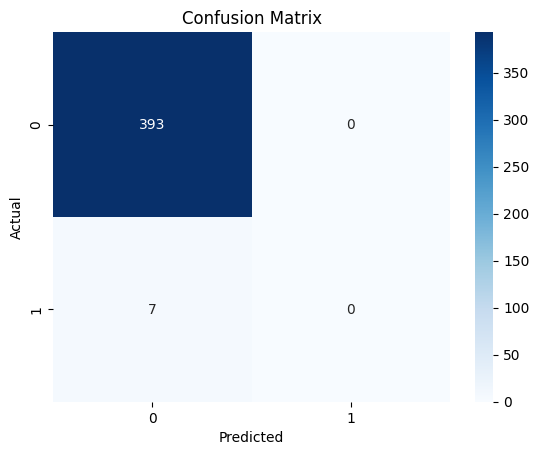

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Classification Report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training Curves

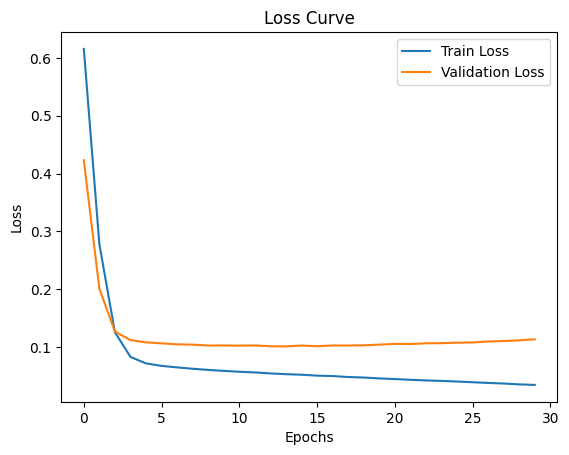

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Task 5: Hyperparameter Experimentation**

Experiment Function

In [ ]:
def build_model(neurons=32, activation='relu', learning_rate=0.001):

    model = Sequential()

    model.add(Dense(neurons, activation=activation, input_dim=X_train.shape[1]))
    model.add(Dense(neurons // 2, activation=activation))
    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

Experiment Configurations

In [ ]:
experiments = [
    {
        "neurons": 32,
        "activation": "relu",
        "learning_rate": 0.001,
        "epochs": 30,
        "batch_size": 32
    },
    {
        "neurons": 64,
        "activation": "relu",
        "learning_rate": 0.0005,
        "epochs": 40,
        "batch_size": 16
    },
    {
        "neurons": 128,
        "activation": "tanh",
        "learning_rate": 0.001,
        "epochs": 50,
        "batch_size": 32
    }
]

Run Experiments

In [ ]:
results = []

for i, config in enumerate(experiments):

    model = build_model(
        neurons=config["neurons"],
        activation=config["activation"],
        learning_rate=config["learning_rate"]
    )

    model.fit(
        X_train,
        y_train,
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        verbose=0
    )

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    results.append({
        "Experiment": i + 1,
        "Neurons": config["neurons"],
        "Activation": config["activation"],
        "Learning Rate": config["learning_rate"],
        "Epochs": config["epochs"],
        "Batch Size": config["batch_size"],
        "Test Accuracy": accuracy
    })

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Comparison Table

In [ ]:
import os

results_df = pd.DataFrame(results)

print(results_df)

# Create the 'results' directory if it doesn't exist
output_dir = 'results'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

results_df.to_csv(
    os.path.join(output_dir, "model_comparison_table.csv"),
    index=False
)

   Experiment  Neurons Activation  Learning Rate  Epochs  Batch Size  \
0           1       32       relu         0.0010      30          32   
1           2       64       relu         0.0005      40          16   
2           3      128       tanh         0.0010      50          32   

   Test Accuracy  
0         0.9775  
1         0.9800  
2         0.9750  


**Task 6: Final Reflection**

In [ ]:
reflection = """
1. Weights and biases help the neural network learn relationships between inputs and outputs.

2. Activation functions introduce non-linearity, allowing the model to solve complex problems.

3. A very high learning rate causes unstable learning, while a very low learning rate slows convergence.

4. Overfitting occurs when training accuracy becomes much higher than testing accuracy.
"""

print(reflection)


1. Weights and biases help the neural network learn relationships between inputs and outputs.

2. Activation functions introduce non-linearity, allowing the model to solve complex problems.

3. A very high learning rate causes unstable learning, while a very low learning rate slows convergence.

4. Overfitting occurs when training accuracy becomes much higher than testing accuracy.

